# Phase unwrapping from the ground up

A phase measurement is an angle, so the instrument reports only a value modulo $2\pi$. The job of unwrapping is to recover a continuous phase field $\phi$ from

$$w = \operatorname{wrap}(\phi)=((\phi+\pi)\bmod 2\pi)-\pi.$$

Every answer has an arbitrary additive constant: if $\phi$ is valid, so is $\phi+c$. We will use a tiny synthetic example so every number can be inspected.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if (SRC / 'parvaneh').is_dir() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from parvaneh import unwrap, rmse_aligned


aligned RMSE: 4.03e-13 rad


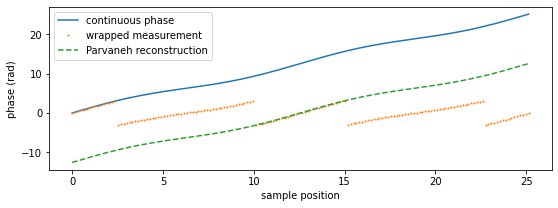

In [2]:
def wrap(x):
    return (x + np.pi) % (2*np.pi) - np.pi

x = np.linspace(0, 8*np.pi, 160)
truth = x + 0.7*np.sin(x/2)
wrapped = wrap(truth)
estimate = unwrap(wrapped, backend='numpy')
print(f'aligned RMSE: {rmse_aligned(estimate, truth):.3g} rad')
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(x, truth, label='continuous phase')
ax.plot(x, wrapped, '.', ms=2, label='wrapped measurement')
ax.plot(x, estimate, '--', label='Parvaneh reconstruction')
ax.set(xlabel='sample position', ylabel='phase (rad)'); ax.legend(); plt.show()


## The algorithm, one step at a time

1. **Measure an angle.** The instrument observes a complex signal $z=Ae^{i\phi}$. Its angle is returned by `atan2`, so only $w\in[-\pi,\pi)$ is known.

2. **Compute a neighbor step.** For adjacent samples, form $d=w_{i+1}-w_i$. Because $d$ may contain a whole turn, reduce it to the principal interval: $\Delta_w=((d+\pi)\bmod 2\pi)-\pi$.

3. **Choose the integer ambiguity.** The unknown integer $k_i$ satisfies $u_{i+1}-u_i=\Delta_w+2\pi k_i$. The local rule chooses the integer that makes the step have smallest magnitude. This is correct when the true step is less than $\pi$; that assumption is Itoh's condition.

4. **Integrate along a path.** Start from an anchor value and repeatedly add corrected steps: $u_{i+1}=u_i+\Delta_w$. The anchor fixes only the arbitrary additive constant.

5. **Check closed loops in 2-D.** Around a cell, add the four oriented wrapped steps. A non-zero multiple of $2\pi$ is a residue. It proves that at least one local integer choice cannot satisfy every edge of that loop simultaneously.

6. **Use a global strategy when paths conflict.** Least squares distributes disagreement by minimizing a gradient error; reliability sorting chooses a high-confidence spanning tree; branch-cut methods block problematic paths; flow methods pair residue charges with integer corrections. The later notebooks implement and compare these choices.

The local rule is therefore not the whole problem: it is the edge measurement used by several global algorithms. Noise, missing pixels, steep gradients, and real discontinuities determine which global strategy is appropriate.